# 03C Real Business Cycle (RBC) Models: Dynamics and Surprise Shocks

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# === Environment Setup ===
import os
import sys
import math
import time
import random
import json
import textwrap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from IPython.display import display, Markdown, Image

# Add scripts directory to path to import utility modules
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), '..', 'scripts'))
try:
    from macro_utils import solve_qz
except ImportError:
    print("Warning: macro_utils not found. Please ensure scripts/macro_utils.py exists.")

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6), 'figure.dpi': 130,
                     'axes.titlesize': 'x-large', 'axes.labelsize': 'large',
                     'xtick.labelsize': 'medium', 'ytick.labelsize': 'medium'})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=140, precision=4)
warnings.filterwarnings('ignore', category=FutureWarning)


# The Lens: Surprise Shocks and Transition Dynamics

**What problem are we solving?**
Once we solve the RBC model, we need to understand how the economy responds to *unexpected* productivity shocks.

**Why this method?**
Impulse-response style simulations translate the linearized solution into time paths for output, consumption, investment, and labor.

### Learning Objectives
* **Simulate** surprise technology shocks in the RBC model.
* **Trace** the dynamic adjustment of macro aggregates.
* **Interpret** the impulse responses in economic terms.

### Prerequisites
* **`04-Macro-Models/03B_RBC_Model_Solution.ipynb`**: Linearized solution and QZ decomposition.
* **`04-Macro-Models/03A_RBC_Model_Foundations.ipynb`**: Equilibrium conditions.
* **`02-Numerical-Methods/01_Linear_Algebra.ipynb`**: Matrix methods.


# Table of Contents
* [The Lens: Surprise Shocks and Transition Dynamics](#The-Lens:-Surprise-Shocks-and-Transition-Dynamics)
* [1. Surprise Shock Dynamics](#1-surprise-shock-dynamics)
* [Summary](#summary)


In [2]:
# --- Base RBC model (from 03B) ---
class RBCModel:
    """
    Implements the canonical Real Business Cycle (RBC) model and solves it using
    the QZ decomposition (Klein's method).

    Reduced System Variables: [k_t, a_t, c_t]
    """
    def __init__(self, alpha=0.33, beta=0.99, delta=0.025, sigma=1.0, phi=1.0, rho_A=0.95, sigma_A=0.01, L_ss=1/3):
        self.alpha, self.beta, self.delta, self.sigma, self.phi = alpha, beta, delta, sigma, phi
        self.rho_A, self.sigma_A, self.L_ss_target = rho_A, sigma_A, L_ss
        self.ss = self._solve_steady_state()
        self.solution = self._solve_model()

    def _solve_steady_state(self):
        r_ss = 1 / self.beta - 1 + self.delta
        ky_ratio = self.alpha / r_ss

        L_ss = self.L_ss_target
        K_ss = ky_ratio ** (1 / (1 - self.alpha)) * L_ss
        Y_ss = K_ss ** self.alpha * L_ss ** (1 - self.alpha)
        I_ss = self.delta * K_ss
        C_ss = Y_ss - I_ss
        w_ss = (1 - self.alpha) * Y_ss / L_ss

        self.psi = w_ss / (C_ss ** self.sigma * L_ss ** self.phi)

        return pd.Series({'Y': Y_ss, 'K': K_ss, 'L': L_ss, 'C': C_ss, 'I': I_ss,
                          'w': w_ss, 'r': r_ss, 'psi': self.psi})

    def _solve_model(self):
        ss = self.ss
        alpha, beta, delta, sigma = self.alpha, self.beta, self.delta, self.sigma
        phi, rho_A = self.phi, self.rho_A
        r_ss = ss.r

        n_vars = 3
        n_states = 2

        AA = np.zeros((n_vars, n_vars))
        BB = np.zeros((n_vars, n_vars))

        denom = phi + alpha
        L_a = 1.0 / denom
        L_k = alpha / denom
        L_c = -sigma / denom

        Y_K = ss.Y / ss.K
        C_K = ss.C / ss.K

        y_a = 1 + (1 - alpha) * L_a
        y_k = alpha + (1 - alpha) * L_k
        y_c = (1 - alpha) * L_c

        AA[0, 0] = 1
        BB[0, 0] = (1 - delta) + Y_K * y_k
        BB[0, 1] = Y_K * y_a
        BB[0, 2] = Y_K * y_c - C_K

        r_a = 1 + (1 - alpha) * L_a
        r_k = (alpha - 1) + (1 - alpha) * L_k
        r_c = (1 - alpha) * L_c

        AA[1, 2] = sigma - beta * r_ss * r_c
        AA[1, 0] = -beta * r_ss * r_k
        AA[1, 1] = -beta * r_ss * r_a
        BB[1, 2] = sigma

        AA[2, 1] = 1
        BB[2, 1] = rho_A

        self.subs = {'L_a': L_a, 'L_k': L_k, 'L_c': L_c,
                     'y_a': y_a, 'y_k': y_k, 'y_c': y_c,
                     'r_a': r_a, 'r_k': r_k, 'r_c': r_c}

        return solve_qz(AA, BB, n_states)

    def reconstruct_variables(self, k, a, c):
        s = self.subs
        l = s['L_a'] * a + s['L_k'] * k + s['L_c'] * c
        y = s['y_a'] * a + s['y_k'] * k + s['y_c'] * c
        i = (self.ss.Y / self.ss.I) * y - (self.ss.C / self.ss.I) * c
        w = y - l
        r = s['r_a'] * a + s['r_k'] * k + s['r_c'] * c
        return l, y, i, w, r

rbc = RBCModel()
print("> **Note:** Base RBC model initialized for dynamics.")

> **Note:** Base RBC model initialized for dynamics.


## 1. Surprise Shock Dynamics

We simulate a 1% unanticipated technology shock at time $t=0$ and trace the model's adjustment over time.


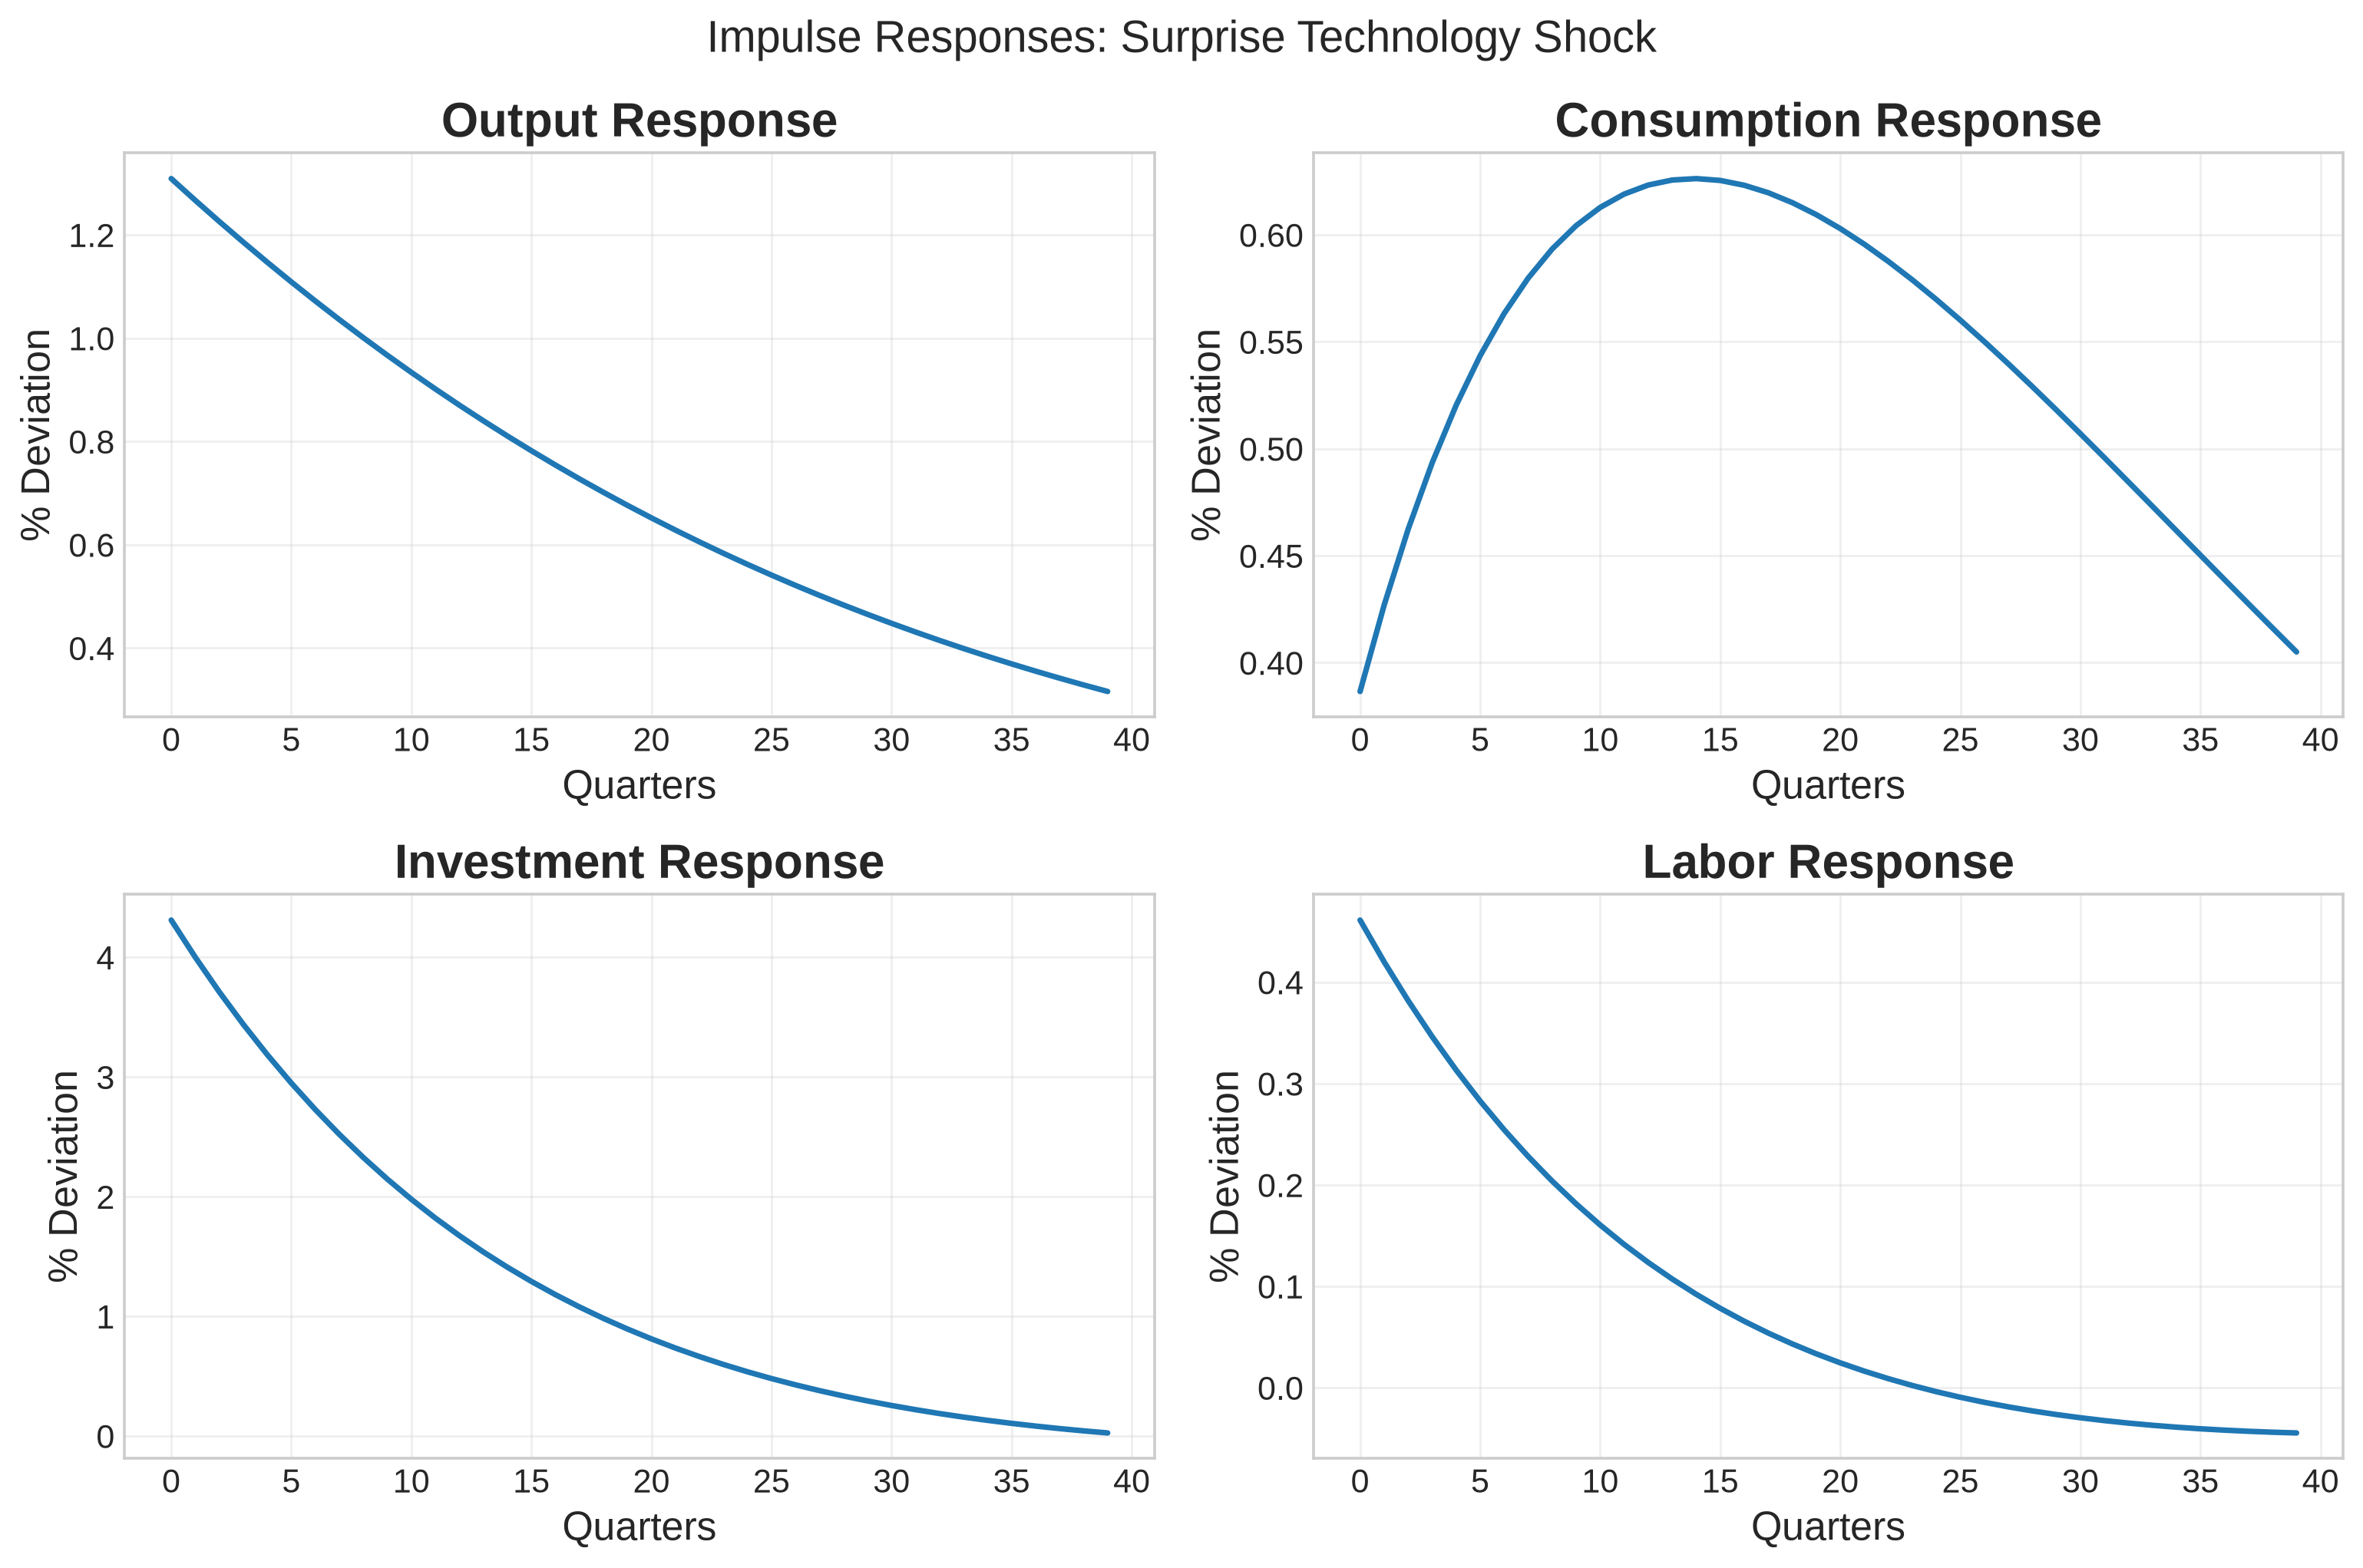

In [3]:
def simulate_surprise_shock(model, T=40, shock=0.01):
    state = np.zeros(2)
    state[1] = shock

    history = {'y': [], 'c': [], 'i': [], 'l': []}
    P = model.solution['Policy']
    Q = model.solution['Transition']

    for _ in range(T):
        c = (P @ state)[0]
        k, a = state[0], state[1]
        l, y, i, w, r = model.reconstruct_variables(k, a, c)
        history['y'].append(y)
        history['c'].append(c)
        history['i'].append(i)
        history['l'].append(l)
        state = Q @ state

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    vars_list = ['Output', 'Consumption', 'Investment', 'Labor']
    keys = ['y', 'c', 'i', 'l']

    for ax, var, key in zip(axes.flatten(), vars_list, keys):
        ax.plot(np.array(history[key]) * 100, linewidth=2)
        ax.set_title(f'{var} Response', fontweight='bold')
        ax.set_xlabel('Quarters')
        ax.set_ylabel('% Deviation')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Impulse Responses: Surprise Technology Shock', fontsize=16)
    plt.tight_layout()
    plt.show()

rbc = RBCModel()
simulate_surprise_shock(rbc)


# Summary

- Surprise productivity shocks generate immediate responses in output, consumption, investment, and labor.
- The impulse responses summarize how the RBC model transmits shocks over time.
